# WEEK 2 - Pre Processing</h1>

In [24]:
import pandas as pd

# load the data

In [25]:
data = pd.read_csv("cardio_train.csv",sep=";")

In [26]:
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


# Drop useless column

In [27]:
data.drop(columns=['id'], inplace=True)

In [28]:
data.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

# Age to years

In [29]:
data["age_days"] = (data["age"] / 365).astype(int)
data.drop(columns=["age"], inplace=True)

In [30]:
data

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_days
0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,1,165,64.0,130,70,3,1,0,0,0,1,51
3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,1,163,72.0,135,80,1,2,0,0,0,1,61


# check for missing values

In [31]:
data.isnull().sum()

gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_days       0
dtype: int64

# BMI CALC AND ADD TO NEW COLUMNS

In [32]:
data["bmi"] = data["weight"] / ((data["height"] / 100) ** 2)

In [33]:
data

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_days,bmi
0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438
69996,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681
69997,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579
69998,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251


In [34]:
data.shape

(70000, 13)

In [35]:
data = data[
    (data["bmi"].between(10, 60)) & 
    (data["ap_hi"].between(50, 250)) &
    (data["ap_lo"].between(30, 150))
].copy()
#high 50-250
#low 30-150
# pressure =high-low

In [36]:
data.shape

(68695, 13)

# Mapping of gender

In [37]:
data.loc[:, "gender"] = data["gender"].map({1: 0, 2: 1})


In [38]:
data

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_days,bmi
0,1,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,0,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,0,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,1,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,0,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,1,168,76.0,120,80,1,1,1,0,1,0,52,26.927438
69996,0,158,126.0,140,90,2,2,0,0,1,1,61,50.472681
69997,1,183,105.0,180,90,3,1,0,1,0,1,52,31.353579
69998,0,163,72.0,135,80,1,2,0,0,0,1,61,27.099251


In [39]:
data.loc[:, "cholesterol"] = data["cholesterol"]-1


In [40]:
data.loc[:, "gluc"] = data["gluc"]-1


In [41]:
data

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_days,bmi
0,1,168,62.0,110,80,0,0,0,0,1,0,50,21.967120
1,0,156,85.0,140,90,2,0,0,0,1,1,55,34.927679
2,0,165,64.0,130,70,2,0,0,0,0,1,51,23.507805
3,1,169,82.0,150,100,0,0,0,0,1,1,48,28.710479
4,0,156,56.0,100,60,0,0,0,0,0,0,47,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,1,168,76.0,120,80,0,0,1,0,1,0,52,26.927438
69996,0,158,126.0,140,90,1,1,0,0,1,1,61,50.472681
69997,1,183,105.0,180,90,2,0,0,1,0,1,52,31.353579
69998,0,163,72.0,135,80,0,1,0,0,0,1,61,27.099251


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
data.loc[:, scale_cols] = scaler.fit_transform(data[scale_cols])
data.head()

C:\Users\khush\AppData\Local\Temp\ipykernel_19460\1746035990.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.45190479 -1.05887356  0.0742102  ...  2.34037772 -0.17758619
  0.70370118]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, scale_cols] = scaler.fit_transform(data[scale_cols])
C:\Users\khush\AppData\Local\Temp\ipykernel_19460\1746035990.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.99224497  0.79984832  0.20248389 ...  3.18930604  0.5011661
 -0.39488054]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, scale_cols] = scaler.fit_transform(data[scale_cols])
C:\Users\khush\AppData\Local\Temp\ipykernel_19460\1746035990.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future er

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_days,bmi
0,1,0.451905,-0.850650,-0.992245,-0.141118,0,0,0,0,1,0,50,-1.051881
1,0,-1.058874,0.767576,0.799848,0.904171,2,0,0,0,1,1,55,1.434887
2,0,0.074210,-0.709934,0.202484,-1.186407,2,0,0,0,0,1,51,-0.756267
3,1,0.577803,0.556503,1.397213,1.949459,0,0,0,0,1,1,48,0.241981
4,0,-1.058874,-1.272795,-1.589609,-2.231695,0,0,0,0,0,0,47,-0.851556


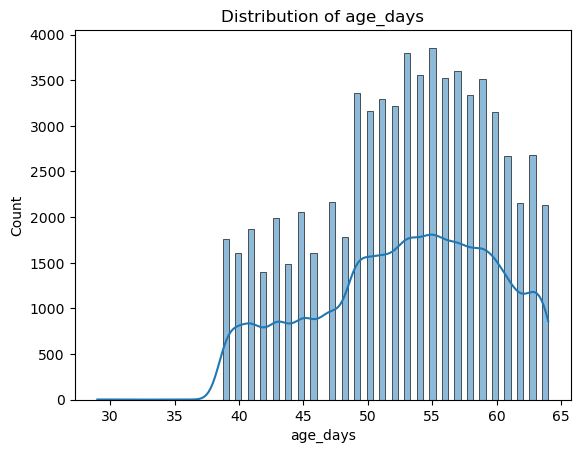

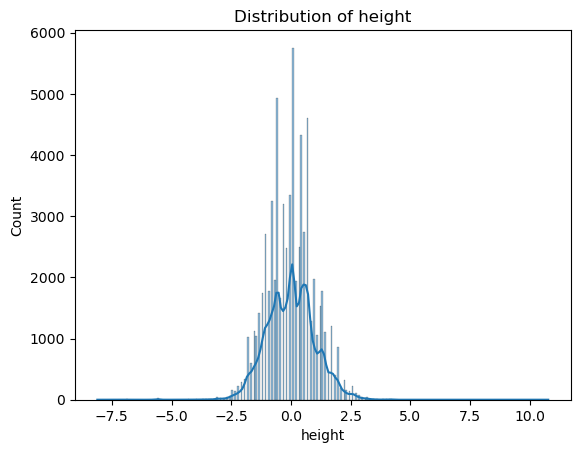

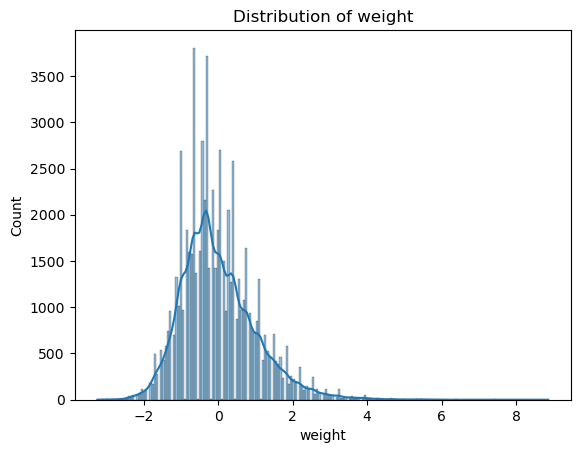

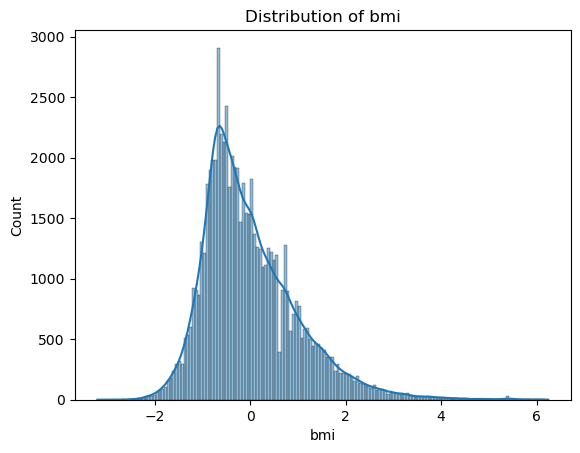

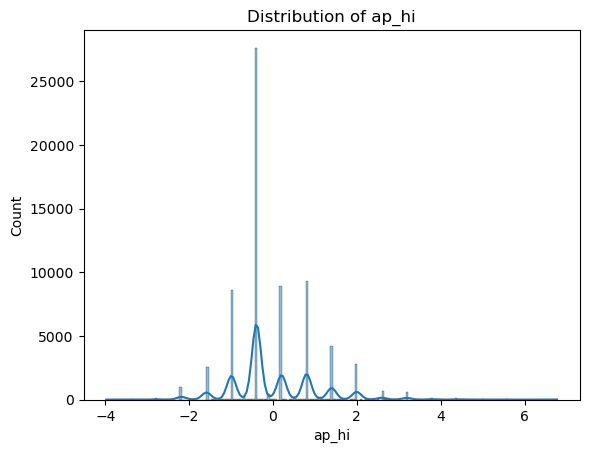

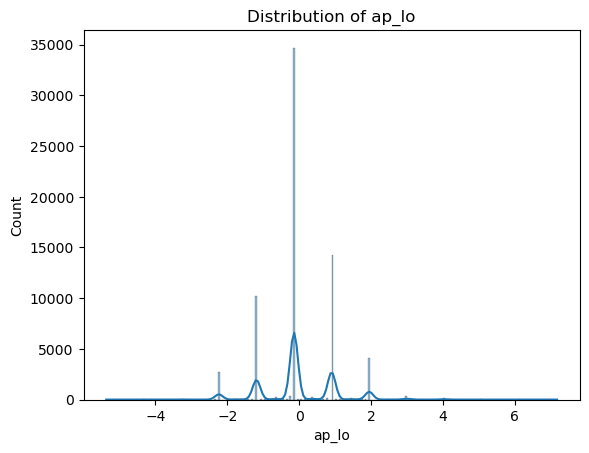

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age_days','height','weight','bmi','ap_hi','ap_lo']

for col in num_cols:
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

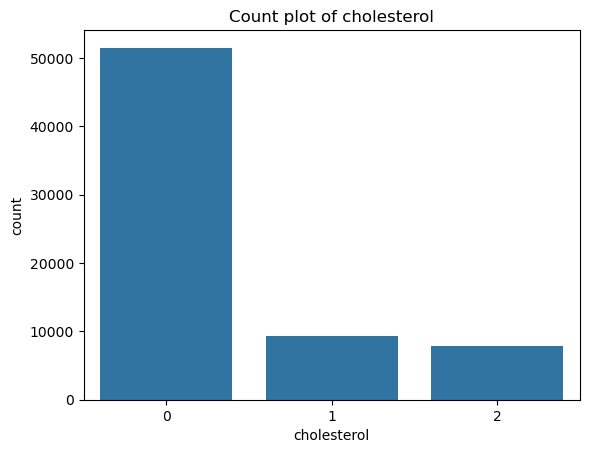

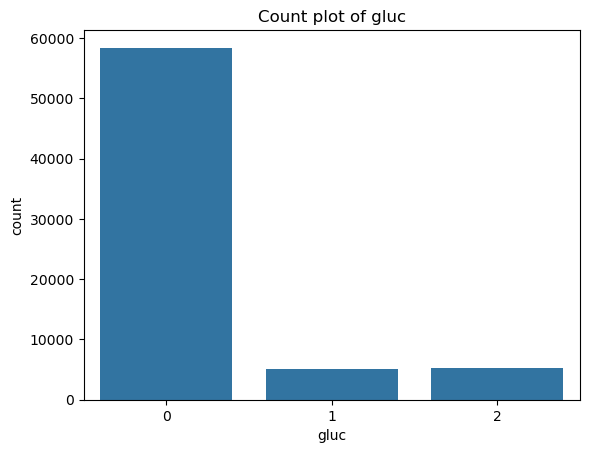

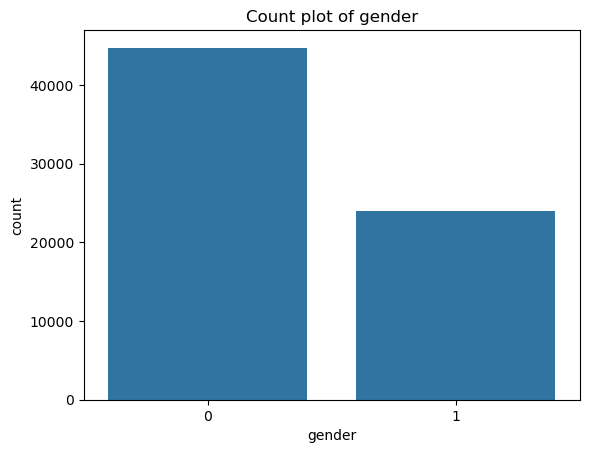

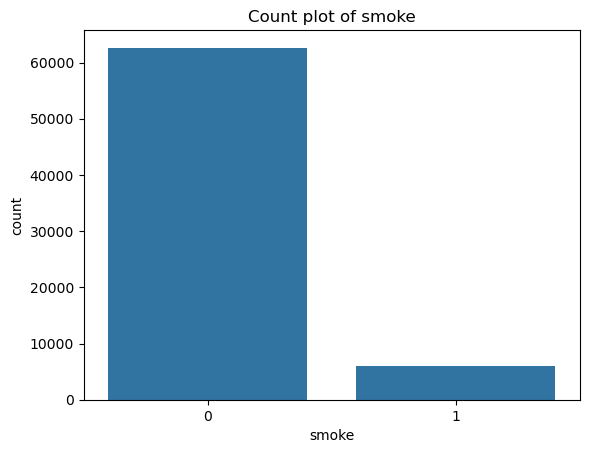

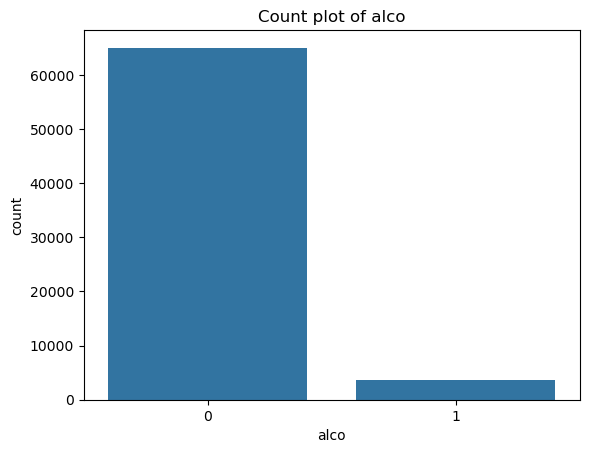

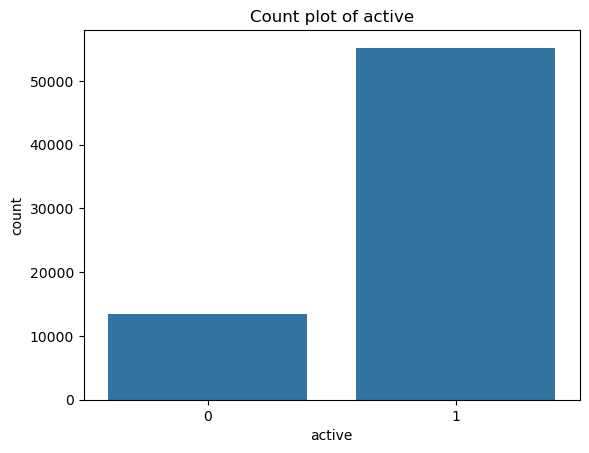

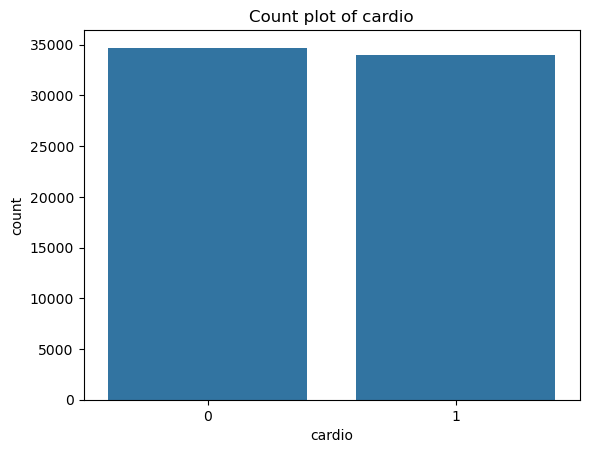

In [44]:
cat_cols = ['cholesterol','gluc','gender','smoke','alco','active','cardio']

for col in cat_cols:
    sns.countplot(x=data[col])
    plt.title(f"Count plot of {col}")
    plt.show()

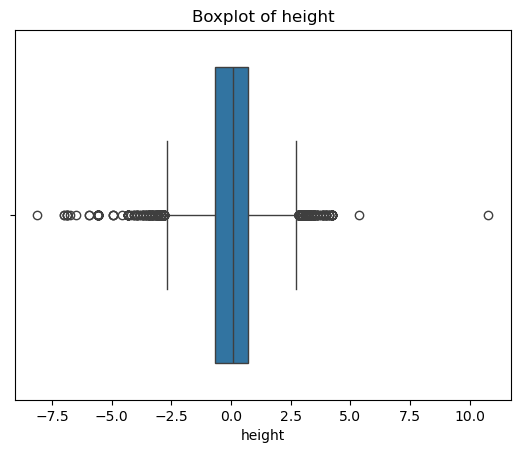

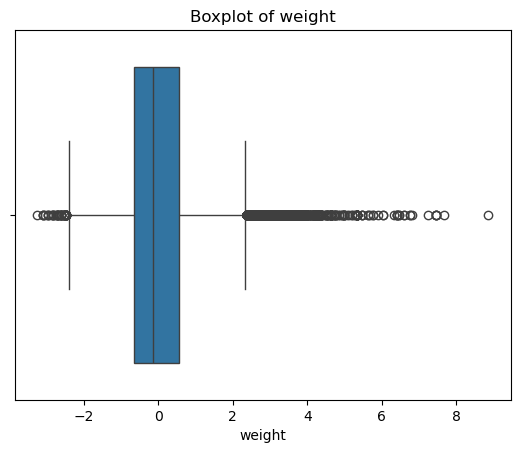

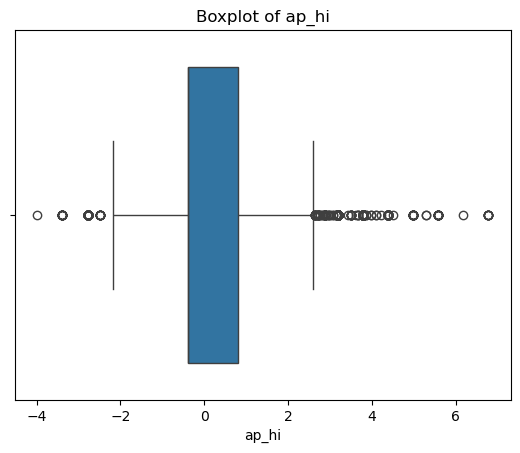

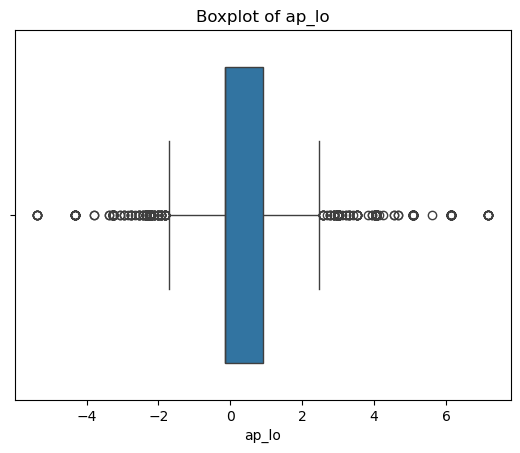

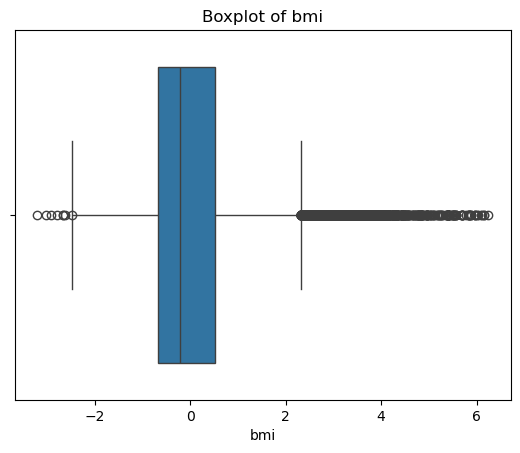

In [45]:
for col in ['height','weight','ap_hi','ap_lo','bmi']:
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


# Save the pre processed data to csv

In [46]:
data.to_csv('preprocessed_data.csv')